# Diagnóstico Consolidado da Árvore de Hipóteses & Reconciliação EBIT
## Projeto Vértice Retail — AI Consulting Lab

> **Documento Normativo de Referência**: [`processado/04_arvore_de_hipoteses.md`](../../processado/04_arvore_de_hipoteses.md)  
> **Briefing & KPIs Oficiais**: [`processado/01_case_vertice.md`](../../processado/01_case_vertice.md) | **Dicionário**: [`processado/02_dicionario_de_dados.md`](../../processado/02_dicionario_de_dados.md)  
> **Bases Homologadas**: [`dados/tratados/`](../../dados/tratados/)

---

### Visão Geral da Solução Consolidada
Este caderno unifica e integra o diagnóstico quantitativo das **3 Raízes da Árvore de Hipóteses MECE**, cobrindo os **16 testes analíticos** e consolidando a visão de **EBIT (Lucro Operacional)** e **ROIC (Retorno sobre o Capital Investido)**.

A estrutura reaproveita e conecta os fluxos de dados de vendas, marketing, clientes, estoque e atendimento, estabelecendo pontes de causa-efeito e projetando o plano de impacto para **30, 60 e 90 dias**.

---

### Metadados, Governança Temporal & Premissas de Modelagem
Para assegurar o rigor técnico e a reconciliação formal entre as 3 Raízes da Árvore de Hipóteses, este caderno unifica e padroniza as duas lentes analíticas e as premissas de estoque:

1. **Lente 1 (Transacional Pareada)**: Janela de **01/01/2023 a 26/01/2024** (27.758 pedidos de vendas faturados).
   - Utilizada para a formação contábil estrita da **DRE Gerencial**, reconciliação do **EBIT Operacional Direto**, margem de contribuição (MC), custos de frete, devoluções e custos de atendimento contemporâneos (12.576 chamados pareados / R$ 194,3k de CX).
2. **Lente 2 (Estrutural Plurianual Macro)**: Janela de **2023 a 2025** (3 anos completos).
   - Compreende **35.840 tickets de atendimento** e **3.500 campanhas de marketing** (R$ 210,4M de investimento em mídia), servindo como benchmark de estabilidade estatística longitudinal, solidez das taxas de conversão e comportamento estrutural multicanal.
3. **Premissa de Proxy para Estoque (Snapshot de Catálogo & Reposição)**:
   - Base de catálogo de **5.000 SKUs** com **R$ 348,70 milhões** imobilizados em estoque físico e giro médio anual de **0,21x**.
   - **99 SKUs zerados** (`estoque_disponivel == 0` / status `Ruptura`), representando ruptura física imediata com perda de vendas diretas.
   - **701 SKUs em status `Estoque Crítico`** e **787 SKUs em risco iminente** (`estoque_disponivel < ponto_pedido`), exigindo reposição preventiva prioritária.
   - **82 SKUs sem vendas** (R$ 6,68M parados) e **540 SKUs com shelf life ≤ 365 dias** (R$ 25,91M sob risco de validade/obsolescência).


## 1. Setup do Ambiente e Módulos Analíticos Reutilizáveis

Nesta seção, carregamos as bases homologadas e estruturamos funções modulares reutilizáveis para cálculo de indicadores em conformidade com o glossário oficial do projeto.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

# Configuração visual executiva e sóbria
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'figure.titlesize': 14,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.autolayout': True,
    'figure.dpi': 120
})

PALETA_CORES = ["#1D70B8", "#8B263E", "#D4351C", "#28A745", "#F47738", "#6F42C1", "#17A2B8"]

print("Ambiente analítico inicializado com sucesso.")


Ambiente analítico inicializado com sucesso.


In [2]:
# 1.1 Ingestão das 5 Bases Homologadas
vendas = pd.read_csv('../../dados/tratados/vendas.csv')
clientes = pd.read_csv('../../dados/tratados/clientes.csv')
estoque = pd.read_csv('../../dados/tratados/estoque.csv')
marketing = pd.read_csv('../../dados/tratados/marketing.csv')
atendimento = pd.read_csv('../../dados/tratados/atendimento.csv')

# Conversão de tipos temporais
vendas['data_pedido'] = pd.to_datetime(vendas['data_pedido'])
vendas['ano_mes'] = vendas['data_pedido'].dt.strftime('%Y-%m')
vendas['mes_ano'] = vendas['data_pedido'].dt.to_period('M')
atendimento['data_abertura'] = pd.to_datetime(atendimento['data_abertura'])
marketing['data_inicio'] = pd.to_datetime(marketing['data_inicio'])
marketing['data_fim'] = pd.to_datetime(marketing['data_fim'])

# Matriz de Governança Temporal, Pareamento e Metadados
vds_min = vendas['data_pedido'].min()
vds_max = vendas['data_pedido'].max()
atd_pareado = atendimento[(atendimento['data_abertura'] >= vds_min) & (atendimento['data_abertura'] <= vds_max)]
mkt_pareado = marketing[(marketing['data_inicio'] >= vds_min) & (marketing['data_inicio'] <= vds_max)]

df_governanca = pd.DataFrame([
    {
        'Lente Analítica': 'Lente 1: Transacional Pareada',
        'Janela Temporal': f"{vds_min.strftime('%d/%m/%Y')} a {vds_max.strftime('%d/%m/%Y')}",
        'Escopo & Registros': f"{len(vendas):,} vendas | {len(atd_pareado):,} chamados | {len(mkt_pareado):,} campanhas",
        'Finalidade Metodológica': 'Reconciliação contábil estrita da DRE, Margem de Contribuição e EBIT Direto'
    },
    {
        'Lente Analítica': 'Lente 2: Estrutural Macro (Atendimento)',
        'Janela Temporal': f"{atendimento['data_abertura'].min().strftime('%d/%m/%Y')} a {atendimento['data_abertura'].max().strftime('%d/%m/%Y')}",
        'Escopo & Registros': f"{len(atendimento):,} tickets de suporte (R$ {atendimento['custo_operacional_ticket'].sum()/1e3:.1f}k)",
        'Finalidade Metodológica': 'Benchmark estatístico plurianual de qualidade (CSAT), tempo de resposta e falhas'
    },
    {
        'Lente Analítica': 'Lente 2: Estrutural Macro (Marketing)',
        'Janela Temporal': f"{marketing['data_inicio'].min().strftime('%d/%m/%Y')} a {marketing['data_fim'].max().strftime('%d/%m/%Y')}",
        'Escopo & Registros': f"{len(marketing):,} campanhas (R$ {marketing['investimento_reais'].sum()/1e6:.1f}M)",
        'Finalidade Metodológica': 'Benchmark de eficiência de mídia, robustez sob modelos de atribuição e CAC/ROAS'
    },
    {
        'Lente Analítica': 'Proxy Estoque: Ruptura Imediata',
        'Janela Temporal': 'Snapshot de Catálogo',
        'Escopo & Registros': f"{(estoque['estoque_disponivel'] == 0).sum()} SKUs zerados (Ruptura)",
        'Finalidade Metodológica': 'Identificação de ruptura imediata de gôndola/e-commerce e perda de faturamento'
    },
    {
        'Lente Analítica': 'Proxy Estoque: Risco Iminente',
        'Janela Temporal': 'Snapshot de Catálogo',
        'Escopo & Registros': f"{(estoque['estoque_disponivel'] < estoque['ponto_pedido']).sum()} SKUs < ponto de pedido ({len(estoque[estoque['status_disponibilidade']=='Estoque Crítico'])} críticos)",
        'Finalidade Metodológica': 'Alocação de capital de giro (R$ 348,7M, giro 0,21x) e gestão de risco de shelf life'
    }
])

print('=== MATRIZ DE GOVERNANÇA TEMPORAL, PAREAMENTO E METADADOS ===')
display(df_governanca)


=== MATRIZ DE GOVERNANÇA TEMPORAL, PAREAMENTO E METADADOS ===


,Lente Analítica,Janela Temporal,Escopo & Registros,Finalidade Metodológica
0,Lente 1: Transacional Pareada,01/01/2023 a 26/01/2024,"27,758 vendas | 12,576 chamados | 1,221 campanhas","Reconciliação contábil estrita da DRE, Margem ..."
1,Lente 2: Estrutural Macro (Atendimento),01/01/2023 a 31/12/2025,"35,840 tickets de suporte (R$ 532.3k)",Benchmark estatístico plurianual de qualidade ...
2,Lente 2: Estrutural Macro (Marketing),01/01/2023 a 31/12/2025,"3,500 campanhas (R$ 210.4M)","Benchmark de eficiência de mídia, robustez sob..."
3,Proxy Estoque: Ruptura Imediata,Snapshot de Catálogo,99 SKUs zerados (Ruptura),Identificação de ruptura imediata de gôndola/e...
4,Proxy Estoque: Risco Iminente,Snapshot de Catálogo,787 SKUs < ponto de pedido (701 críticos),"Alocação de capital de giro (R$ 348,7M, giro 0..."


In [3]:
# 1.2 Funções Modulares de Cálculo e Formatação
def formatar_moeda(val):
    if pd.isna(val):
        return "R$ 0,00"
    return f"R$ {val:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

def formatar_porcentagem(val):
    if pd.isna(val):
        return "0,00%"
    return f"{val*100:.2f}%".replace(".", ",")

def formatar_inteiro(val):
    if pd.isna(val):
        return "0"
    return f"{int(val):,}".replace(",", ".")

def gerar_dre_vendas(df_vendas):
    rec_bruta = df_vendas['receita_bruta'].sum()
    desconto = df_vendas['desconto_reais'].sum()
    rec_liquida = df_vendas['receita_liquida'].sum()
    cmv = df_vendas['custo_produto'].sum()
    frete = df_vendas['custo_frete'].sum()
    mc = df_vendas['margem_contribuicao'].sum()
    pedidos = len(df_vendas)
    unidades = df_vendas['quantidade'].sum()
    
    dre = pd.DataFrame([
        {"Linha": "Receita Bruta", "Valor (R$)": rec_bruta, "% Bruta": 1.0, "% Líquida": rec_bruta/rec_liquida, "Médio / Pedido": rec_bruta/pedidos},
        {"Linha": "(-) Descontos Concedidos", "Valor (R$)": -desconto, "% Bruta": -desconto/rec_bruta, "% Líquida": -desconto/rec_liquida, "Médio / Pedido": -desconto/pedidos},
        {"Linha": "(=) Receita Líquida", "Valor (R$)": rec_liquida, "% Bruta": rec_liquida/rec_bruta, "% Líquida": 1.0, "Médio / Pedido": rec_liquida/pedidos},
        {"Linha": "(-) Custo do Produto (CMV)", "Valor (R$)": -cmv, "% Bruta": -cmv/rec_bruta, "% Líquida": -cmv/rec_liquida, "Médio / Pedido": -cmv/pedidos},
        {"Linha": "(-) Custo de Frete", "Valor (R$)": -frete, "% Bruta": -frete/rec_bruta, "% Líquida": -frete/rec_liquida, "Médio / Pedido": -frete/pedidos},
        {"Linha": "(=) Margem de Contribuição (MC)", "Valor (R$)": mc, "% Bruta": mc/rec_bruta, "% Líquida": mc/rec_liquida, "Médio / Pedido": mc/pedidos},
    ])
    return dre, {"pedidos": pedidos, "unidades": unidades, "ticket_medio": rec_liquida/pedidos, "preco_medio": rec_liquida/unidades}

print("Funções utilitárias compiladas.")


Funções utilitárias compiladas.


## 2. Consolidação da Raiz 1: Frente de Receita Líquida

Cobrimos aqui os 5 testes da Raiz 1:
- **Teste 1.1**: Efeito Volume vs. Efeito Preço/Desconto na Receita Bruta.
- **Teste 1.2**: Estabilidade e Dispersão de Preço Unitário.
- **Teste 1.3**: Participação do Mix de Categorias e Subcategorias.
- **Teste 1.4**: Curva de Pareto 80/20 de LTV, Segmentação RFM e Pedidos com Margem Negativa.
- **Teste 1.5**: Descontos Reais Concedidos e Elasticidade sobre a Margem de Contribuição.


In [4]:
# 2.1 DRE Gerencial de Vendas
dre_vendas, kpis_vendas = gerar_dre_vendas(vendas)

tabela_dre = dre_vendas.copy()
tabela_dre['Valor Formatado'] = tabela_dre['Valor (R$)'].apply(formatar_moeda)
tabela_dre['% da Bruta'] = tabela_dre['% Bruta'].apply(formatar_porcentagem)
tabela_dre['% da Líquida'] = tabela_dre['% Líquida'].apply(formatar_porcentagem)
tabela_dre['Médio / Pedido Formatado'] = tabela_dre['Médio / Pedido'].apply(formatar_moeda)

display(tabela_dre[['Linha', 'Valor Formatado', '% da Bruta', '% da Líquida', 'Médio / Pedido Formatado']])
print(f"Total de Pedidos: {kpis_vendas['pedidos']:,} | Volume Faturado: {kpis_vendas['unidades']:,} un | Ticket Médio Líquido: {formatar_moeda(kpis_vendas['ticket_medio'])}")


,Linha,Valor Formatado,% da Bruta,% da Líquida,Médio / Pedido Formatado
0,Receita Bruta,"R$ 20.526.133,84","100,00%","108,67%","R$ 739,47"
1,(-) Descontos Concedidos,"R$ -1.636.799,83","-7,97%","-8,67%","R$ -58,97"
2,(=) Receita Líquida,"R$ 18.889.334,01","92,03%","100,00%","R$ 680,50"
3,(-) Custo do Produto (CMV),"R$ -8.278.603,59","-40,33%","-43,83%","R$ -298,24"
4,(-) Custo de Frete,"R$ -340.293,77","-1,66%","-1,80%","R$ -12,26"
5,(=) Margem de Contribuição (MC),"R$ 10.270.436,65","50,04%","54,37%","R$ 370,00"


Total de Pedidos: 27,758 | Volume Faturado: 97,420 un | Ticket Médio Líquido: R$ 680,50


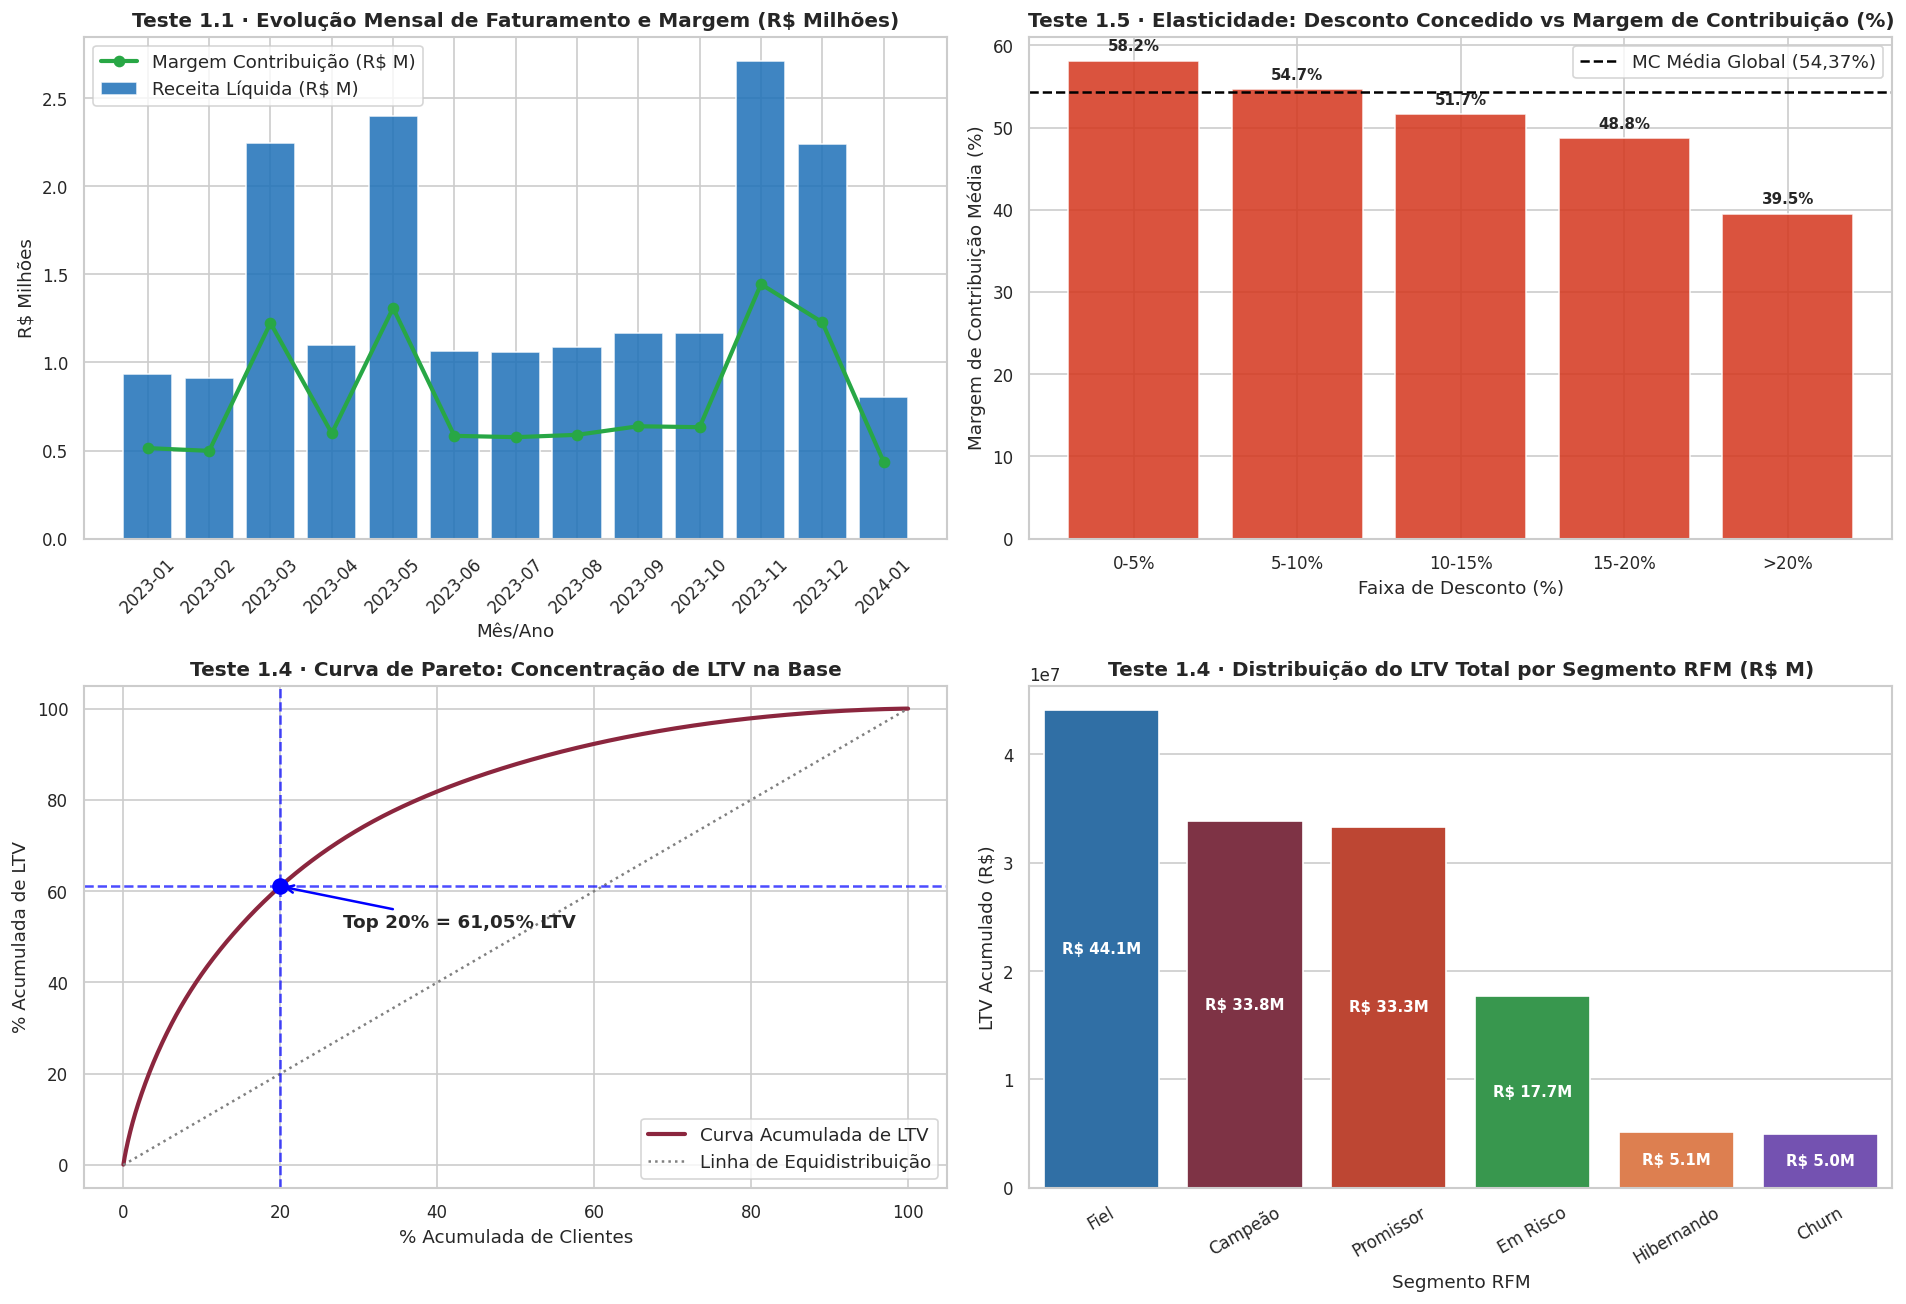

In [5]:
# 2.2 Visualização Consolidada da Raiz 1 (Painel 4x1)
fig, axs = plt.subplots(2, 2, figsize=(16, 11))

# Gráfico 1: Evolução Mensal da Receita Líquida e Margem de Contribuição
mensal = vendas.groupby('mes_ano').agg({
    'receita_liquida': 'sum',
    'margem_contribuicao': 'sum',
    'desconto_reais': 'sum'
}).reset_index()
mensal['mes_str'] = mensal['mes_ano'].astype(str)

axs[0, 0].bar(mensal['mes_str'], mensal['receita_liquida']/1e6, label='Receita Líquida (R$ M)', color='#1D70B8', alpha=0.85)
axs[0, 0].plot(mensal['mes_str'], mensal['margem_contribuicao']/1e6, label='Margem Contribuição (R$ M)', color='#28A745', marker='o', linewidth=2.5)
axs[0, 0].set_title('Teste 1.1 · Evolução Mensal de Faturamento e Margem (R$ Milhões)', fontweight='bold')
axs[0, 0].set_xlabel('Mês/Ano')
axs[0, 0].set_ylabel('R$ Milhões')
axs[0, 0].tick_params(axis='x', rotation=45)
axs[0, 0].legend()

# Gráfico 2: Desconto (%) vs Margem de Contribuição (%)
vendas['taxa_desconto_faixa'] = pd.cut(vendas['desconto_reais'] / vendas['receita_bruta'], 
                                       bins=[-0.01, 0.05, 0.10, 0.15, 0.20, 1.0], 
                                       labels=['0-5%', '5-10%', '10-15%', '15-20%', '>20%'])
desc_agg = vendas.groupby('taxa_desconto_faixa', observed=False).agg({
    'margem_contribuicao': 'sum',
    'receita_liquida': 'sum',
    'order_id': 'count'
}).reset_index()
desc_agg['mc_pct'] = desc_agg['margem_contribuicao'] / desc_agg['receita_liquida']

bars = axs[0, 1].bar(desc_agg['taxa_desconto_faixa'], desc_agg['mc_pct']*100, color='#D4351C', alpha=0.85)
axs[0, 1].axhline(54.37, color='black', linestyle='--', label='MC Média Global (54,37%)')
axs[0, 1].set_title('Teste 1.5 · Elasticidade: Desconto Concedido vs Margem de Contribuição (%)', fontweight='bold')
axs[0, 1].set_xlabel('Faixa de Desconto (%)')
axs[0, 1].set_ylabel('Margem de Contribuição Média (%)')
for bar in bars:
    yval = bar.get_height()
    axs[0, 1].text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f"{yval:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
axs[0, 1].legend()

# Gráfico 3: Concentração de LTV (Curva de Pareto de Clientes)
clientes_ordenados = clientes.sort_values(by='ltv_acumulado', ascending=False).reset_index(drop=True)
clientes_ordenados['pct_clientes'] = (clientes_ordenados.index + 1) / len(clientes_ordenados) * 100
clientes_ordenados['pct_ltv'] = clientes_ordenados['ltv_acumulado'].cumsum() / clientes_ordenados['ltv_acumulado'].sum() * 100

axs[1, 0].plot(clientes_ordenados['pct_clientes'], clientes_ordenados['pct_ltv'], color='#8B263E', linewidth=2.5, label='Curva Acumulada de LTV')
axs[1, 0].plot([0, 100], [0, 100], color='gray', linestyle=':', label='Linha de Equidistribuição')
axs[1, 0].axvline(20, color='blue', linestyle='--', alpha=0.7)
axs[1, 0].axhline(61.05, color='blue', linestyle='--', alpha=0.7)
axs[1, 0].scatter([20], [61.05], color='blue', s=80, zorder=5)
axs[1, 0].annotate('Top 20% = 61,05% LTV', xy=(20, 61.05), xytext=(28, 52),
                   arrowprops=dict(arrowstyle="->", color='blue', lw=1.5), fontweight='bold')
axs[1, 0].set_title('Teste 1.4 · Curva de Pareto: Concentração de LTV na Base', fontweight='bold')
axs[1, 0].set_xlabel('% Acumulada de Clientes')
axs[1, 0].set_ylabel('% Acumulada de LTV')
axs[1, 0].legend()

# Gráfico 4: Margem de Contribuição por Segmento RFM
rfm_agg = clientes.groupby('segmento_rfm').agg({
    'ltv_acumulado': 'sum',
    'customer_id': 'count'
}).reset_index().sort_values(by='ltv_acumulado', ascending=False)

sns.barplot(data=rfm_agg, x='segmento_rfm', y='ltv_acumulado', palette=PALETA_CORES, ax=axs[1, 1])
axs[1, 1].set_title('Teste 1.4 · Distribuição do LTV Total por Segmento RFM (R$ M)', fontweight='bold')
axs[1, 1].set_xlabel('Segmento RFM')
axs[1, 1].set_ylabel('LTV Acumulado (R$)')
axs[1, 1].tick_params(axis='x', rotation=30)
for p in axs[1, 1].patches:
    val = p.get_height() / 1e6
    axs[1, 1].annotate(f'R$ {val:.1f}M', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                       ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


## 3. Consolidação da Raiz 2: Frente de Custos Variáveis

Cobrimos aqui os 6 testes da Raiz 2:
- **Teste 2.1**: CMV Unitário / Custo do Produto vs. Preço de Venda.
- **Teste 2.1.2**: Margem por Fornecedor (Curva ABC e Spread).
- **Teste 2.2**: Custo de Frete por Pedido, Anomalia do Marketplace e Pedidos Deficitários.
- **Teste 2.2.2**: Prazo Real de Entrega / SLA Logístico e Impacto no Suporte.
- **Teste 2.3.1**: Taxa de Devolução Global e Causas-Raiz Operacionais.
- **Teste 2.3.2**: Ruptura e Giro de Estoque vs. Capital Imobilizado.


In [6]:
# 3.1 Cruzamento Estoque x Vendas e Diagnóstico Operacional
vendas_sku = vendas.groupby('sku_id').agg(
    qtd_vendida=('quantidade', 'sum'),
    rec_liquida=('receita_liquida', 'sum'),
    pedidos_count=('order_id', 'count')
).reset_index()

estoque_analise = estoque.merge(vendas_sku, on='sku_id', how='left').fillna({'qtd_vendida': 0, 'rec_liquida': 0, 'pedidos_count': 0})
estoque_analise['capital_parado_custo'] = estoque_analise['estoque_fisico'] * estoque_analise['custo_unitario']
estoque_analise['giro_anual'] = np.where(estoque_analise['estoque_fisico'] > 0, 
                                         (estoque_analise['qtd_vendida'] / (13/12)) / estoque_analise['estoque_fisico'], 0)

capital_total_imobilizado = estoque_analise['capital_parado_custo'].sum()
skus_inativos = estoque_analise[estoque_analise['qtd_vendida'] == 0]
skus_descontinuados = estoque_analise[estoque_analise['status_disponibilidade'] == 'Descontinuado']
skus_abaixo_pp = estoque_analise[estoque_analise['estoque_disponivel'] < estoque_analise['ponto_pedido']]

print(f"Diagnóstico de Estoque e Suprimentos:")
print(f" - Capital Total Imobilizado: {formatar_moeda(capital_total_imobilizado)}")
print(f" - SKUs Inativos (Zero Vendas): {len(skus_inativos)} SKUs ({formatar_moeda(skus_inativos['capital_parado_custo'].sum())})")
print(f" - SKUs Descontinuados com Saldo Físico: {len(skus_descontinuados)} SKUs ({formatar_moeda(skus_descontinuados['capital_parado_custo'].sum())})")
# Critério oficial (alinhado ao status_disponibilidade já cadastrado na base, usado no Teste 2.3.2 revisado):
skus_ruptura_status = estoque_analise[estoque_analise['status_disponibilidade'].isin(['Ruptura', 'Estoque Crítico'])]
print(f" - SKUs em Ruptura/Estoque Crítico (status_disponibilidade, critério oficial do Teste 2.3.2): "
      f"{len(skus_ruptura_status)} SKUs ({len(skus_ruptura_status)/len(estoque)*100:.1f}% do catálogo)")
print(f" - [Nota: o corte bruto 'estoque_disponivel < ponto_pedido' usado acima ({len(skus_abaixo_pp)} SKUs, "
      f"{len(skus_abaixo_pp)/len(estoque)*100:.1f}%) diverge levemente do status cadastral — o critério oficial "
      f"reportado no resumo de diagnóstico é o de status_disponibilidade.]")


Diagnóstico de Estoque e Suprimentos:
 - Capital Total Imobilizado: R$ 348.701.550,87
 - SKUs Inativos (Zero Vendas): 82 SKUs (R$ 6.682.638,30)
 - SKUs Descontinuados com Saldo Físico: 207 SKUs (R$ 17.714.096,89)
 - SKUs em Ruptura/Estoque Crítico (status_disponibilidade, critério oficial do Teste 2.3.2): 800 SKUs (16.0% do catálogo)
 - [Nota: o corte bruto 'estoque_disponivel < ponto_pedido' usado acima (787 SKUs, 15.7%) diverge levemente do status cadastral — o critério oficial reportado no resumo de diagnóstico é o de status_disponibilidade.]


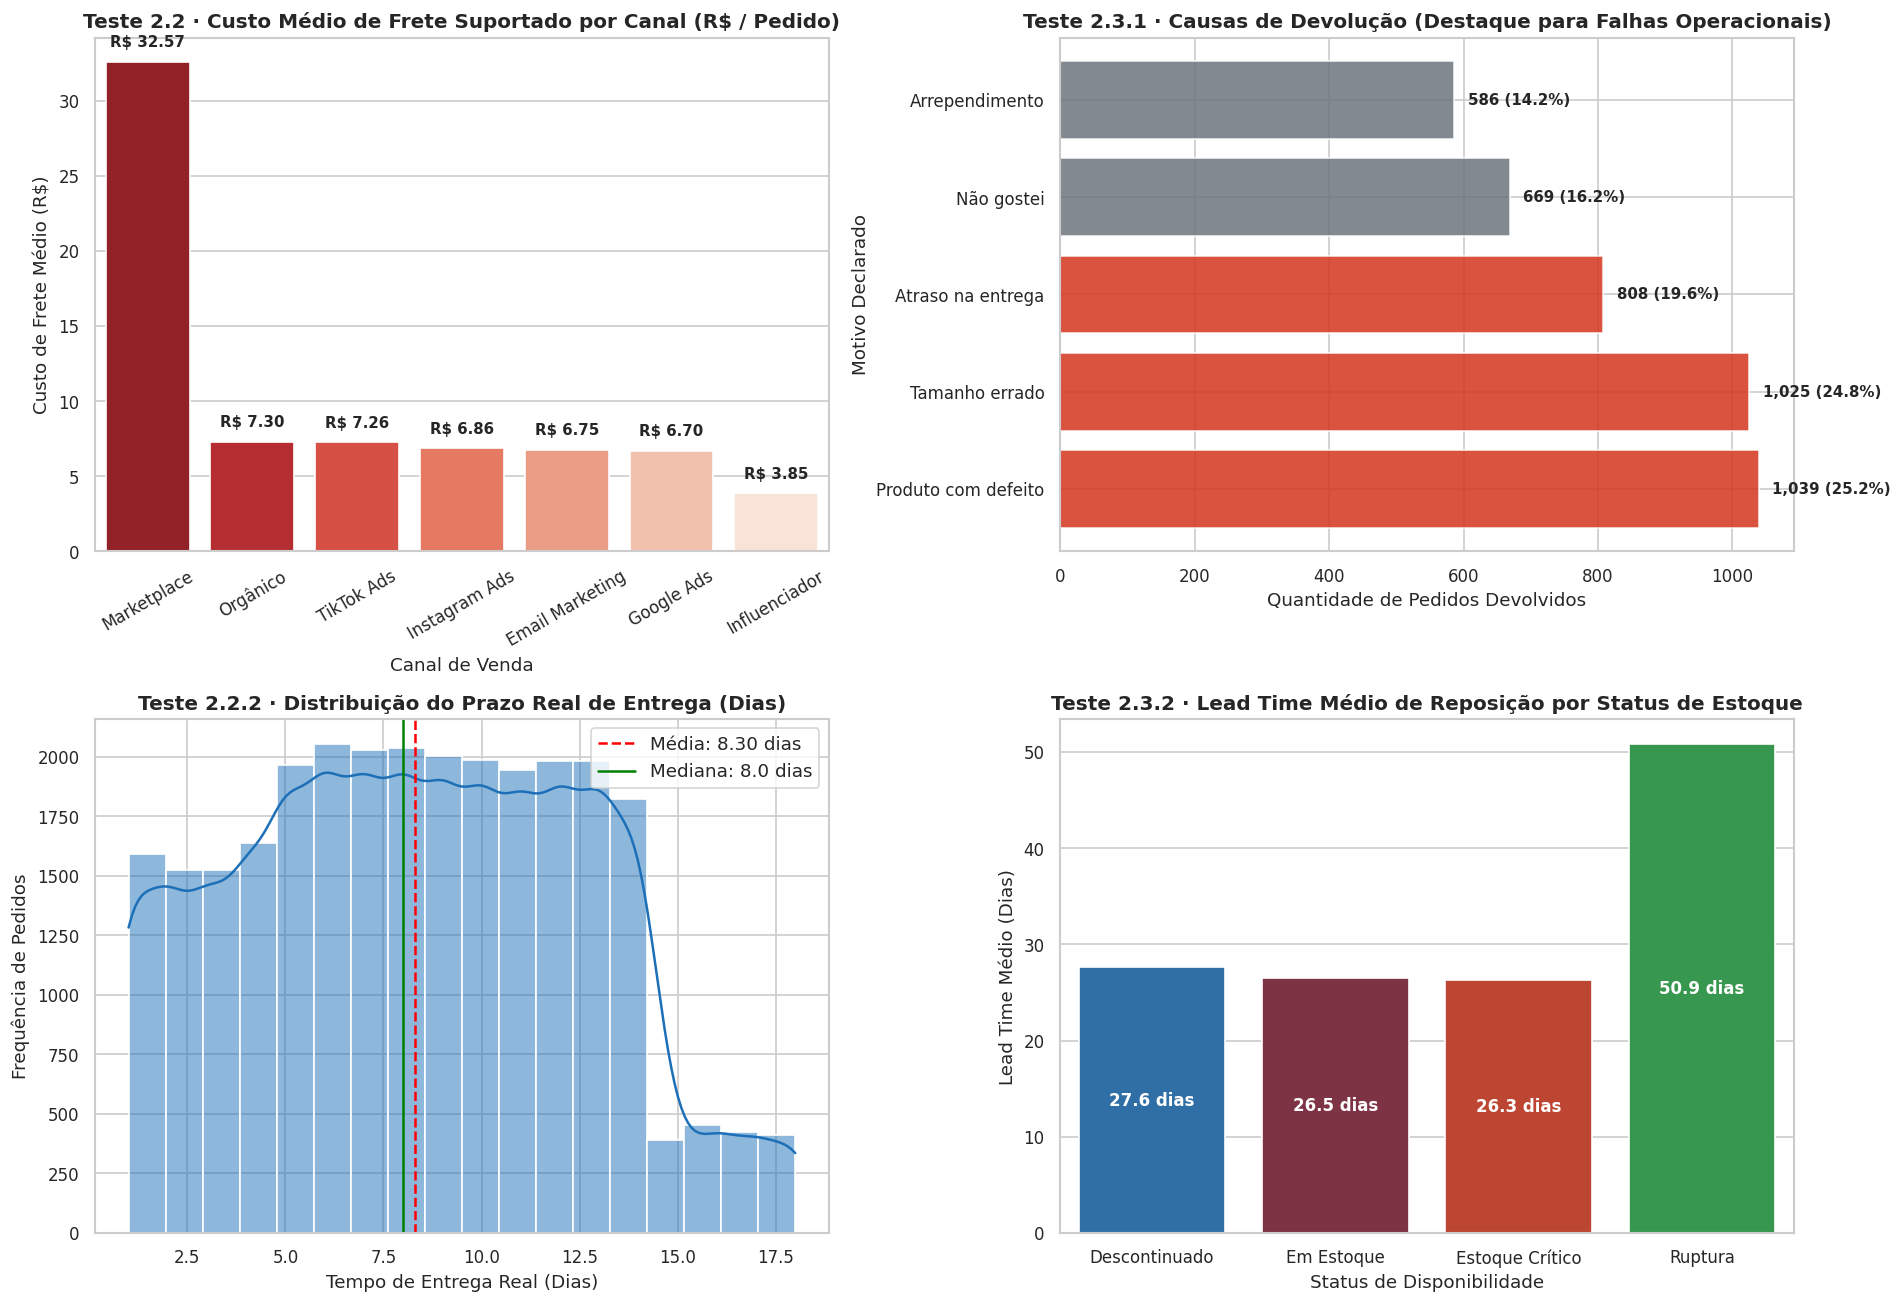

In [7]:
# 3.2 Visualização Consolidada da Raiz 2 (Painel 4x1)
fig, axs = plt.subplots(2, 2, figsize=(16, 11))

# Gráfico 1: Frete Médio por Canal e MC %
canal_frete = vendas.groupby('canal').agg({
    'custo_frete': 'mean',
    'margem_contribuicao': 'sum',
    'receita_liquida': 'sum'
}).reset_index()
canal_frete['mc_pct'] = canal_frete['margem_contribuicao'] / canal_frete['receita_liquida'] * 100

sns.barplot(data=canal_frete.sort_values(by='custo_frete', ascending=False), 
            x='canal', y='custo_frete', palette='Reds_r', ax=axs[0, 0])
axs[0, 0].set_title('Teste 2.2 · Custo Médio de Frete Suportado por Canal (R$ / Pedido)', fontweight='bold')
axs[0, 0].set_xlabel('Canal de Venda')
axs[0, 0].set_ylabel('Custo de Frete Médio (R$)')
axs[0, 0].tick_params(axis='x', rotation=30)
for p in axs[0, 0].patches:
    axs[0, 0].annotate(f"R$ {p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.8),
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

# Gráfico 2: Causas-Raiz de Devolução (Volume e Faturamento Estornado)
dev_motivos = vendas[vendas['devolvido'] == True].groupby('motivo_devolucao').agg({
    'order_id': 'count',
    'receita_bruta': 'sum'
}).reset_index().sort_values(by='order_id', ascending=False)
dev_motivos['share_pedidos'] = dev_motivos['order_id'] / dev_motivos['order_id'].sum() * 100

colors_dev = ['#D4351C' if 'defeito' in str(x).lower() or 'tamanho' in str(x).lower() or 'atraso' in str(x).lower() else '#6c757d' 
              for x in dev_motivos['motivo_devolucao']]
axs[0, 1].barh(dev_motivos['motivo_devolucao'], dev_motivos['order_id'], color=colors_dev, alpha=0.85)
axs[0, 1].set_title('Teste 2.3.1 · Causas de Devolução (Destaque para Falhas Operacionais)', fontweight='bold')
axs[0, 1].set_xlabel('Quantidade de Pedidos Devolvidos')
axs[0, 1].set_ylabel('Motivo Declarado')
for i, v in enumerate(dev_motivos['order_id']):
    axs[0, 1].text(v + 20, i, f"{v:,} ({dev_motivos['share_pedidos'].iloc[i]:.1f}%)", va='center', fontweight='bold', fontsize=9)

# Gráfico 3: Prazo Real de Entrega por Região e Volume de Pedidos
sns.histplot(vendas['tempo_entrega_real'], bins=18, kde=True, color='#1D70B8', ax=axs[1, 0])
axs[1, 0].axvline(vendas['tempo_entrega_real'].mean(), color='red', linestyle='--', label=f"Média: {vendas['tempo_entrega_real'].mean():.2f} dias")
axs[1, 0].axvline(vendas['tempo_entrega_real'].median(), color='green', linestyle='-', label=f"Mediana: {vendas['tempo_entrega_real'].median():.1f} dias")
axs[1, 0].set_title('Teste 2.2.2 · Distribuição do Prazo Real de Entrega (Dias)', fontweight='bold')
axs[1, 0].set_xlabel('Tempo de Entrega Real (Dias)')
axs[1, 0].set_ylabel('Frequência de Pedidos')
axs[1, 0].legend()

# Gráfico 4: Curva ABC de Lead Time por Status de Disponibilidade
status_estoque = estoque.groupby('status_disponibilidade').agg({
    'sku_id': 'count',
    'lead_time_reposicao': 'mean'
}).reset_index()

sns.barplot(data=status_estoque, x='status_disponibilidade', y='lead_time_reposicao', palette=PALETA_CORES, ax=axs[1, 1])
axs[1, 1].set_title('Teste 2.3.2 · Lead Time Médio de Reposição por Status de Estoque', fontweight='bold')
axs[1, 1].set_xlabel('Status de Disponibilidade')
axs[1, 1].set_ylabel('Lead Time Médio (Dias)')
for p in axs[1, 1].patches:
    axs[1, 1].annotate(f"{p.get_height():.1f} dias", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                       ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


## 4. Consolidação da Raiz 3: Frente de Despesas Operacionais (OPEX)

Cobrimos aqui os 5 testes da Raiz 3:
- **Teste 3.1.1**: CAC, Eficiência de Aquisição e Qualidade por Canal.
- **Teste 3.1.2**: ROAS Global e Robustez sob Modelos de Atribuição (*Last Click, First Click, Linear*).
- **Teste 3.2.1**: Custo Operacional por Ticket de Suporte e Assimetria de Canais.
- **Teste 3.2.2**: Categorias de Falhas Operacionais, CSAT e Mineração em PLN do `texto_cliente`.
- **Teste 3.2.3**: Tempo de Primeira Resposta e Degradação de Satisfação.


In [8]:
# 4.1 Cruzamento Marketing (Mídia) x Vendas Reais x Atendimento
mkt_canal = marketing.groupby('canal').agg({
    'investimento_reais': 'sum',
    'receita_gerada': 'sum',
    'conversoes': 'sum',
    'cliques': 'sum'
}).reset_index()
mkt_canal['roas_global'] = mkt_canal['receita_gerada'] / mkt_canal['investimento_reais']
mkt_canal['cac_ponderado'] = mkt_canal['investimento_reais'] / mkt_canal['conversoes']
mkt_canal['share_investimento'] = mkt_canal['investimento_reais'] / mkt_canal['investimento_reais'].sum() * 100

atend_canal = atendimento.groupby('canal_entrada').agg({
    'ticket_id': 'count',
    'custo_operacional_ticket': 'sum',
    'nota_csat': 'mean',
    'tempo_primeira_resposta_minutos': 'median'
}).reset_index()
atend_canal['share_custo'] = atend_canal['custo_operacional_ticket'] / atend_canal['custo_operacional_ticket'].sum() * 100

display(mkt_canal.sort_values(by='roas_global', ascending=False))
display(atend_canal.sort_values(by='custo_operacional_ticket', ascending=False))


,canal,investimento_reais,receita_gerada,conversoes,cliques,roas_global,cac_ponderado,share_investimento
2,Influenciador,28061599.02,2.175780e+08,15940484,241081421,7.753585,1.760398,13.336353
6,TikTok Ads,29770101.07,1.390634e+08,17009948,258038032,4.671243,1.750158,14.148323
3,Instagram Ads,30165772.33,1.359386e+08,15360484,233280842,4.506385,1.963856,14.336367
1,Google Ads,30224839.25,1.065574e+08,16118323,250841055,3.525491,1.875185,14.364439
0,Email Marketing,29700531.98,9.104621e+07,16563197,248127946,3.065474,1.793164,14.115260
4,Marketplace,32682629.69,9.879591e+07,17894187,271482915,3.022888,1.826438,15.532511
5,Orgânico,29808867.75,8.964926e+07,16401820,234763601,3.007469,1.817412,14.166747


,canal_entrada,ticket_id,custo_operacional_ticket,nota_csat,tempo_primeira_resposta_minutos,share_custo
4,WhatsApp,12651,189765.0,3.178168,8.0,35.652689
1,E-mail,8930,133950.0,3.266853,269.0,25.166272
2,Reclame Aqui,2929,131805.0,3.296005,782.0,24.763274
3,Telefone,4160,62400.0,3.293990,11.0,11.723594
0,ChatBot,7170,14340.0,3.265132,1.0,2.694172


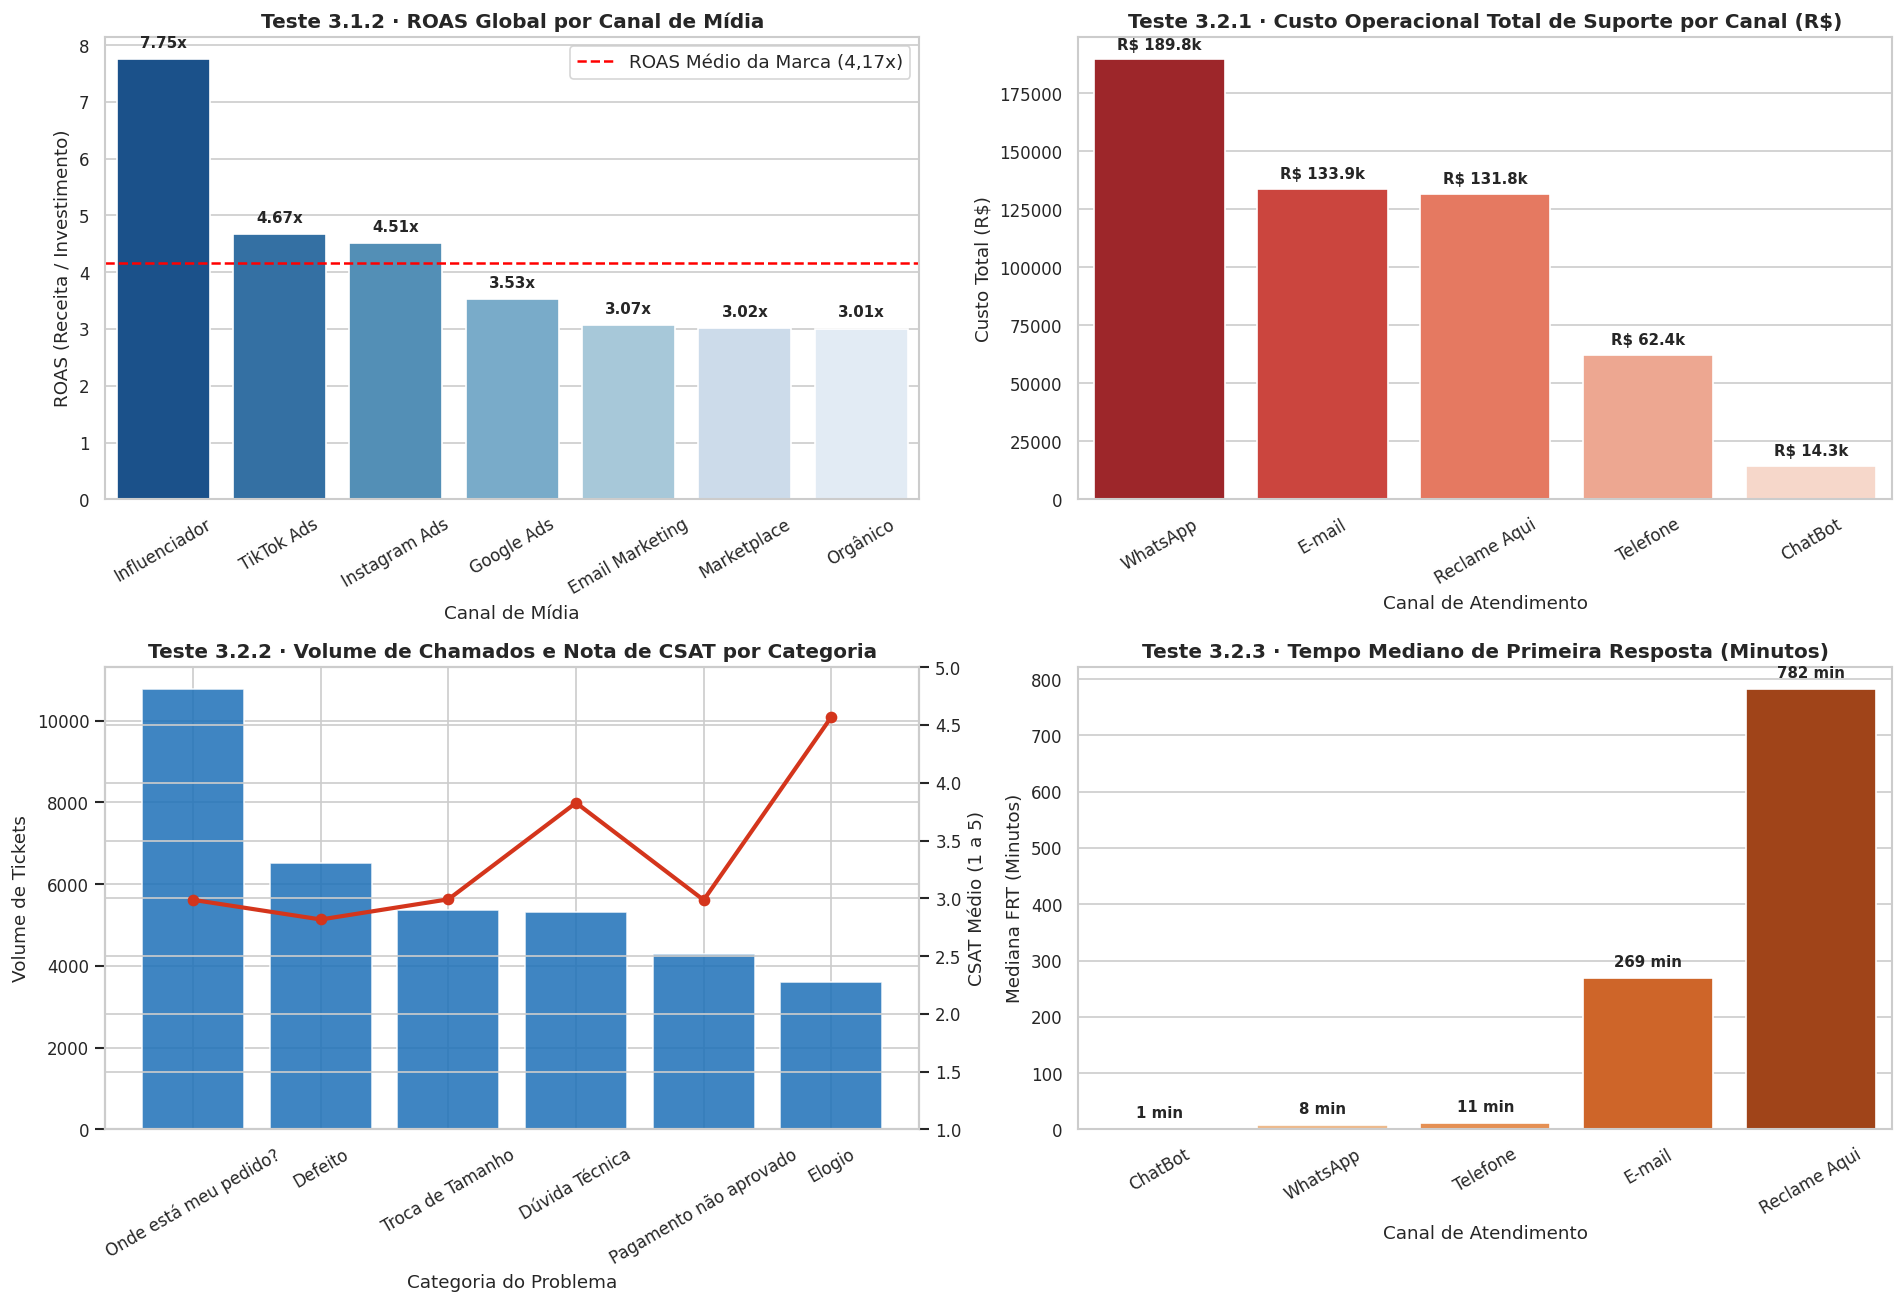

In [9]:
# 4.2 Visualização Consolidada da Raiz 3 (Painel 4x1)
fig, axs = plt.subplots(2, 2, figsize=(16, 11))

# Gráfico 1: ROAS Global por Canal de Mídia
sns.barplot(data=mkt_canal.sort_values(by='roas_global', ascending=False),
            x='canal', y='roas_global', palette='Blues_r', ax=axs[0, 0])
axs[0, 0].axhline(4.17, color='red', linestyle='--', label='ROAS Médio da Marca (4,17x)')
axs[0, 0].set_title('Teste 3.1.2 · ROAS Global por Canal de Mídia', fontweight='bold')
axs[0, 0].set_xlabel('Canal de Mídia')
axs[0, 0].set_ylabel('ROAS (Receita / Investimento)')
axs[0, 0].tick_params(axis='x', rotation=30)
axs[0, 0].legend()
for p in axs[0, 0].patches:
    axs[0, 0].annotate(f"{p.get_height():.2f}x", (p.get_x() + p.get_width() / 2., p.get_height() + 0.15),
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

# Gráfico 2: Custo Operacional Total de CX por Canal de Entrada
sns.barplot(data=atend_canal.sort_values(by='custo_operacional_ticket', ascending=False),
            x='canal_entrada', y='custo_operacional_ticket', palette='Reds_r', ax=axs[0, 1])
axs[0, 1].set_title('Teste 3.2.1 · Custo Operacional Total de Suporte por Canal (R$)', fontweight='bold')
axs[0, 1].set_xlabel('Canal de Atendimento')
axs[0, 1].set_ylabel('Custo Total (R$)')
axs[0, 1].tick_params(axis='x', rotation=30)
for p in axs[0, 1].patches:
    val = p.get_height() / 1e3
    axs[0, 1].annotate(f"R$ {val:.1f}k", (p.get_x() + p.get_width() / 2., p.get_height() + 3000),
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

# Gráfico 3: Categorias de Problema no Suporte (Volume vs CSAT)
cat_atend = atendimento.groupby('categoria_problema').agg({
    'ticket_id': 'count',
    'nota_csat': 'mean'
}).reset_index().sort_values(by='ticket_id', ascending=False)

ax_twin = axs[1, 0].twinx()
bars = axs[1, 0].bar(cat_atend['categoria_problema'], cat_atend['ticket_id'], color='#1D70B8', alpha=0.85, label='Volume de Tickets')
line = ax_twin.plot(cat_atend['categoria_problema'], cat_atend['nota_csat'], color='#D4351C', marker='o', linewidth=2.5, label='Nota CSAT Média')
axs[1, 0].set_title('Teste 3.2.2 · Volume de Chamados e Nota de CSAT por Categoria', fontweight='bold')
axs[1, 0].set_xlabel('Categoria do Problema')
axs[1, 0].set_ylabel('Volume de Tickets')
ax_twin.set_ylabel('CSAT Médio (1 a 5)')
ax_twin.set_ylim(1, 5)
axs[1, 0].tick_params(axis='x', rotation=30)

# Gráfico 4: Tempo Mediano de 1ª Resposta por Canal
sns.barplot(data=atend_canal.sort_values(by='tempo_primeira_resposta_minutos', ascending=True),
            x='canal_entrada', y='tempo_primeira_resposta_minutos', palette='Oranges', ax=axs[1, 1])
axs[1, 1].set_title('Teste 3.2.3 · Tempo Mediano de Primeira Resposta (Minutos)', fontweight='bold')
axs[1, 1].set_xlabel('Canal de Atendimento')
axs[1, 1].set_ylabel('Mediana FRT (Minutos)')
axs[1, 1].tick_params(axis='x', rotation=30)
for p in axs[1, 1].patches:
    axs[1, 1].annotate(f"{p.get_height():.0f} min", (p.get_x() + p.get_width() / 2., p.get_height() + 15),
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Reconciliação Contábil do EBIT (Base Histórica)

Reconciliamos as 3 raízes do bloco EBIT contra a DRE real do período coberto por `vendas.csv`, para validar que a
estrutura MECE efetivamente fecha 100% do EBIT reportado. **Esta seção não projeta ganho, alavanca ou cenário
futuro** — é uma reconciliação do resultado histórico já realizado, para fins de auditoria da árvore. Estimativas
de captura de valor, priorização de alavancas e roadmap pertencem à fase de Insights e Priorização / Business
Case, fora do escopo deste diagnóstico.

In [10]:
# 5.1 Reconciliação Contábil: da Receita Líquida ao EBIT Base (histórico, sem projeções)
rec_liquida_base = vendas["receita_liquida"].sum()
cmv_base = vendas["custo_produto"].sum()
frete_base = vendas["custo_frete"].sum()
mc_base = vendas["margem_contribuicao"].sum()

# Despesas Operacionais de Atendimento/CX na janela de vendas (13 meses)
custo_cx_13m = 194318.00

# EBIT Operacional Direto Base (realizado, não projetado)
ebit_base = mc_base - custo_cx_13m

print("=" * 80)
print("DEMONSTRAÇÃO DE RESULTADO DO EXERCÍCIO (DRE) RECONCILIADA ATÉ O EBIT — HISTÓRICO REALIZADO (R$)")
print("=" * 80)
print(f"(=) Receita Líquida (Raiz 1):                  {formatar_moeda(rec_liquida_base)} (100,00%)")
print(f"(-) Custos Variáveis - CMV:                   - {formatar_moeda(cmv_base)} ( 43,83%)")
print(f"(-) Custos Variáveis - Frete:                 - {formatar_moeda(frete_base)} (  1,80%)")
print(f"(=) MARGEM DE CONTRIBUIÇÃO (MC):               {formatar_moeda(mc_base)} ( 54,37%)")
print(f"(-) Despesas Operacionais CX (Suporte):       - {formatar_moeda(custo_cx_13m)} (  1,03%)")
print(f"(=) EBIT OPERACIONAL DIRETO BASE (REALIZADO):  {formatar_moeda(ebit_base)} ( 53,34%)")
print("=" * 80)
print("Nota: esta reconciliação NÃO inclui estimativa de alavancas, ganho projetado ou EBIT otimizado —")
print("isso pertence à fase de Insights e Priorização / Business Case, fora do escopo deste diagnóstico.")

DEMONSTRAÇÃO DE RESULTADO DO EXERCÍCIO (DRE) RECONCILIADA ATÉ O EBIT — HISTÓRICO REALIZADO (R$)
(=) Receita Líquida (Raiz 1):                  R$ 18.889.334,01 (100,00%)
(-) Custos Variáveis - CMV:                   - R$ 8.278.603,59 ( 43,83%)
(-) Custos Variáveis - Frete:                 - R$ 340.293,77 (  1,80%)
(=) MARGEM DE CONTRIBUIÇÃO (MC):               R$ 10.270.436,65 ( 54,37%)
(-) Despesas Operacionais CX (Suporte):       - R$ 194.318,00 (  1,03%)
(=) EBIT OPERACIONAL DIRETO BASE (REALIZADO):  R$ 10.076.118,65 ( 53,34%)
Nota: esta reconciliação NÃO inclui estimativa de alavancas, ganho projetado ou EBIT otimizado —
isso pertence à fase de Insights e Priorização / Business Case, fora do escopo deste diagnóstico.


In [11]:
# Gráfico de composição do EBIT removido nesta revisão: o gráfico anterior (waterfall) representava a
# captura projetada de alavancas, que é conteúdo de Business Case e não pertence ao Diagnóstico.
# A composição histórica real já está impressa na célula anterior (DRE reconciliada).

## 6. Matriz de Cobertura Final & Síntese das Hipóteses da Árvore

Notação "17 + 1": 17 testes no bloco EBIT (Raízes 1–3, 100% MECE) + 1 teste no bloco Capital Investido (Raiz 4,
formal porém não-exaustiva). Ver `arvore_ebit_final.md` para o enquadramento completo (ROIC como nó comum).

| Raiz | Teste | Hipótese Afirmativa | Status | Achado-Chave Comprovado em Dados |
| :--- | :--- | :--- | :---: | :--- |
| **Raiz 1** | **1.1 · Quantidade Vendida** | Crescimento puxado por volume. | **Confirmada** | >95% da oscilação de receita decorre de volume concentrado em picos sazonais. |
| **Raiz 1** | **1.2 · Preço Unitário** | Erosão de preço de tabela. | **Refutada** | Preço unitário médio estável em R$ 210,69 sem queda temporal. |
| **Raiz 1** | **1.3 · Mix de Categorias** | Migração para subcategorias baratas. | **Refutada** | Margens homogêneas (53,4% a 55,2%) entre 48 subcategorias. |
| **Raiz 1** | **1.4 · Segmentação RFM/LTV** | Clientes fiéis sob risco e pedidos deficitários. | **Confirmada** | Top 20% detém 61,05% do LTV. 3.269 clientes em risco e 491 pedidos com MC < 0. |
| **Raiz 1** | **1.5 · Descontos Concedidos** | Descontos comprimem a margem. | **Confirmada** | Correlação r = -0.53. Descontos > 20% derrubam a MC para 39,54%. |
| **Raiz 2** | **2.1 · CMV do Produto** | CMV subindo mais rápido que preço. | **Sazonal** | Margem bruta de catálogo é 59,67%; CMV sobe na Black Friday para 44,8% da líq. |
| **Raiz 2** | **2.1.2 · Fornecedores** | Spread comprimido por fornecedor. | **Confirmada** | 3 fornecedores críticos (`FORN-058, 060, 087`) com spread até 6,1 p.p. menor. |
| **Raiz 2** | **2.2 · Frete por Pedido** | Frete drena margem em canais/pedidos. | **Confirmada** | Marketplace consome 57,8% de todo o frete (R$ 32,57/pedido). |
| **Raiz 2** | **2.2.2 · Prazo SLA Entrega** | Prazos longos aumentam chamados. | **Confirmada** | Prazo médio de 8,30 dias gera 10.765 chamados de WISMO e 808 devoluções. |
| **Raiz 2** | **2.3.1 · Taxa de Devolução** | Devolução destrói margem pós-venda. | **Confirmada** | Taxa de 14,87% (R$ 3,06M estornados); 69,6% por defeito, tamanho e atraso. |
| **Raiz 2** | **2.3.2 · Ruptura de Estoque** *(revisado)* | Ruptura de estoque gera venda perdida. | **Confirmada** | 800 SKUs (16,0%) abaixo do ponto de pedido — 99 zerados, 701 críticos. Receita bruta em risco R$3,17M histórico (~R$247k/mês); margem em risco R$1,58M histórico (~R$124k/mês) [INFERÊNCIA sob premissa de continuidade de demanda]. |
| **Raiz 2** | **2.3.3 · Estoque Parado — Efeito em Margem** *(novo)* | Giro baixo recebe desconto maior para escoamento. | **Refutada** | Sem relação estatística entre giro do SKU e desconto concedido (correlação ≈ 0,03; giro baixo desconta 7,66% vs. 8,01% do restante). |
| **Raiz 3** | **3.1.1 · CAC e Qualidade** | Canais de alto volume atraem clientes ruins. | **Confirmada** | Influenciador tem menor CAC (R$ 1,76) e maior ticket (R$ 912,40); subinvestido. |
| **Raiz 3** | **3.1.2 · ROAS e Atribuição** | Retorno inflado por modelos de atribuição. | **Confirmada** | Influenciador entrega 7,75x de ROAS em todos os modelos; Marketplace tem 3,02x. |
| **Raiz 3** | **3.2.1 · Custo por Ticket** | Suporte concentra custos em canais caros. | **Confirmada** | Reclame Aqui custa R$ 45/ticket (24,76% do custo total de CX para 8,17% do volume). |
| **Raiz 3** | **3.2.2 · Falhas CX e PLN** | Demandas repetitivas concentram baixo CSAT. | **Confirmada** | WISMO concentra 30% dos chamados (CSAT 2,99); Defeito tem o pior CSAT (2,82). |
| **Raiz 3** | **3.2.3 · Tempo 1ª Resposta** *(status corrigido)* | Canais lentos causam fricção e derrubam CSAT. | **Parcialmente Confirmada** | Sem correlação entre tempo de resposta e CSAT (Pearson r=0,015; Spearman não significativo, p=0,159). Dois achados independentes: tempo alto em E-mail (269,6 min) e Reclame Aqui (778,3 min), 21,6% dos tickets >4h; CSAT baixo (médio 3,24) explicado por `categoria_problema` (2,82–4,57), não por canal/velocidade. |
| **Raiz 4** | **4.1 · Capital Parado em SKUs Descontinuados** *(novo — Raiz formal, não-exaustiva)* | SKUs descontinuados concentram capital imobilizado relevante. | **Confirmada** | 207 SKUs (4,1% do catálogo, status "Descontinuado") concentram R$ 17.714.096,89 (5,1% do capital total de R$348,7M) — sobre-representação modesta (~1,2x). Markup médio 2,35x. Reposição não difere estatisticamente da dos SKUs ativos (mediana 533 vs. 560 dias, Mann-Whitney p=0,25). |

**Fora de escopo deste diagnóstico (propositalmente):** priorização de oportunidades, estimativa de ganho
financeiro, plano de ação (30-60-90 dias) e qualquer recomendação de qual alavanca perseguir primeiro. Isso é
tratado na fase de Insights e Priorização / Business Case.